<a href="https://colab.research.google.com/github/fahad15fede/Assignment-AI-ML/blob/main/Polynomial_Regression_Manufacturing_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('manufacturing.csv')

display(df.head())

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06,100.000000


In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3957 entries, 0 to 3956
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Temperature (°C)                3957 non-null   float64
 1   Pressure (kPa)                  3957 non-null   float64
 2   Temperature x Pressure          3957 non-null   float64
 3   Material Fusion Metric          3957 non-null   float64
 4   Material Transformation Metric  3957 non-null   float64
 5   Quality Rating                  3957 non-null   float64
dtypes: float64(6)
memory usage: 185.6 KB


None

In [ ]:
df.shape

(3957, 6)

In [ ]:
df.isna().sum()

,0
Temperature (°C),0
Pressure (kPa),0
Temperature x Pressure,0
Material Fusion Metric,0
Material Transformation Metric,0
Quality Rating,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
display(df.describe())

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
count,3957.000000,3957.000000,3957.000000,3957.000000,3.957000e+03,3957.000000
mean,200.034704,14.815558,2955.321308,48127.183128,1.003645e+07,96.260179
std,58.135717,5.772040,1458.224940,23812.213513,7.599356e+06,12.992262
min,100.014490,5.003008,513.706875,10156.971955,9.999462e+05,1.000000
25%,150.871296,9.692984,1798.247303,27626.929091,3.433810e+06,99.941129
50%,198.603371,14.832557,2678.277782,44611.452164,7.833390e+06,99.999997
75%,251.366552,19.749680,3929.058261,67805.443846,1.588251e+07,100.000000
max,299.992804,24.999132,7365.018714,103756.181544,2.699783e+07,100.000000


### Separating Numerical Features and Applied Column Transformer and Standard Scaling on Numerical Features

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features (X) and target (y)
X = df.drop('Quality Rating', axis=1)
y = df['Quality Rating']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numerical_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features)
    ])

### Creating ML Pipeline For Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

# Create a pipeline for Linear Regression
linear_regression_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train the Linear Regression model
linear_regression_pipeline.fit(X_train, y_train)

print("Linear Regression model trained.")

Linear Regression model trained.


### Creating ML Pipeline for Polynomial Regression

In [ ]:
# Create a pipeline for Polynomial Regression
polynomial_regression_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', LinearRegression())
])

# Train the Polynomial Regression model
polynomial_regression_pipeline.fit(X_train, y_train)

print("Polynomial Regression model trained.")

Polynomial Regression model trained.


### Model Evaluation


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

# Make predictions
y_pred_linear = linear_regression_pipeline.predict(X_test)
y_pred_polynomial = polynomial_regression_pipeline.predict(X_test)

# Evaluate Linear Regression
r2_linear = r2_score(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)

# Evaluate Polynomial Regression
r2_polynomial = r2_score(y_test, y_pred_polynomial)
mse_polynomial = mean_squared_error(y_test, y_pred_polynomial)

print("Linear Regression Evaluation:")
print(f"  R-squared: {r2_linear:.4f}")
print(f"  Mean Squared Error: {mse_linear:.4f}")
print("\nPolynomial Regression Evaluation:")
print(f"  R-squared: {r2_polynomial:.4f}")
print(f"  Mean Squared Error: {mse_polynomial:.4f}")

Linear Regression Evaluation:
  R-squared: 0.5146
  Mean Squared Error: 99.1026

Polynomial Regression Evaluation:
  R-squared: 0.9264
  Mean Squared Error: 15.0277


### Model Comparison
Let's compare the R-squared and MSE values to see which model performed better.

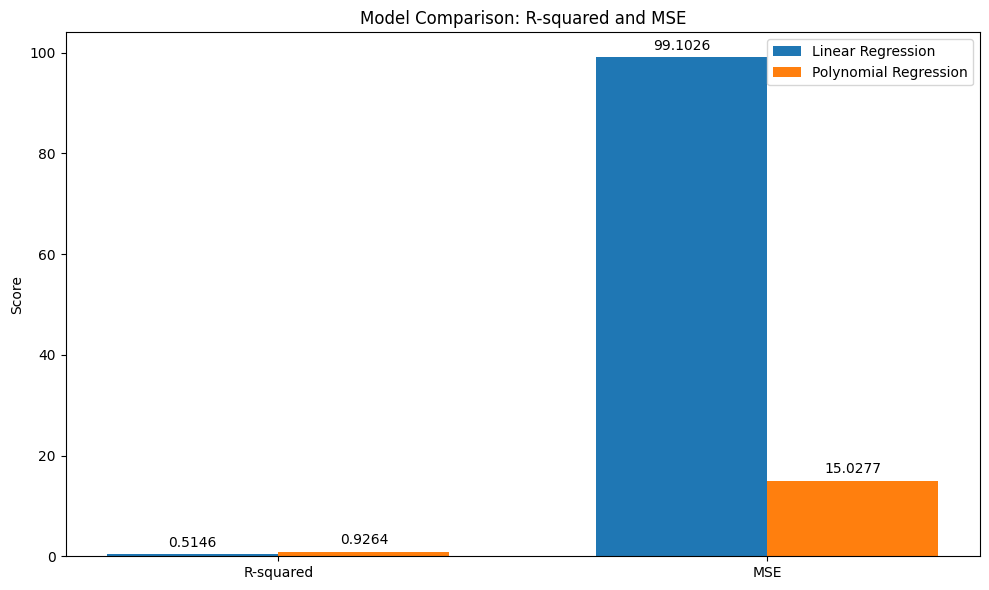

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['R-squared', 'MSE']
linear_scores = [r2_linear, mse_linear]
polynomial_scores = [r2_polynomial, mse_polynomial]

x = np.arange(len(metrics))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, linear_scores, width, label='Linear Regression')
rects2 = ax.bar(x + width/2, polynomial_scores, width, label='Polynomial Regression')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_title('Model Comparison: R-squared and MSE')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

### Save Models


In [ ]:
import pickle

# Save Linear Regression model
with open('linear_regression_model.pkl', 'wb') as f:
    pickle.dump(linear_regression_pipeline, f)
print("Linear Regression model saved to 'linear_regression_model.pkl'")

# Save Polynomial Regression model
with open('polynomial_regression_model.pkl', 'wb') as f:
    pickle.dump(polynomial_regression_pipeline, f)
print("Polynomial Regression model saved to 'polynomial_regression_model.pkl'")

Linear Regression model saved to 'linear_regression_model.pkl'
Polynomial Regression model saved to 'polynomial_regression_model.pkl'
